# Добровольский А.В. ИУ5-23М
## Лабораторная работа №5

**Тема:** обучение с подкреплением, динамическое программирование, Policy Iteration.  
**Среда:** `MountainCar-v0` из Gymnasium

Классический Policy Iteration работает с конечным MDP, то есть с конечным числом состояний. У `MountainCar-v0` состояние непрерывное: положение автомобиля и скорость. Поэтому в работе используется дискретизация состояния:

- `position` разбивается на интервалы;
- `velocity` разбивается на интервалы;
- каждая пара интервалов считается дискретным состоянием.

После этого строится приближенная таблица переходов `P(s'|s,a)` и наград `R(s,a)`, а затем применяется Policy Iteration.

## 1. Установка библиотек


In [1]:
!pip install gymnasium

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 953.9/953.9 kB 11.6 MB/s  0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ---------- ----------------------------- 1/4 [typing-extensions]
   -------------------- ------------------- 2/4 [cloudpickle]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------

## 2. Импорт библиотек

In [2]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 6)

## 3. Создание среды



In [3]:
class MountainCarFallback:
    """Минимальная Gymnasium-подобная реализация MountainCar-v0.
    Используется только если gymnasium не установлен.
    """
    def __init__(self):
        self.min_position = -1.2
        self.max_position = 0.6
        self.max_speed = 0.07
        self.goal_position = 0.5
        self.force = 0.001
        self.gravity = 0.0025
        self.max_episode_steps = 200
        self.state = None
        self.rng = np.random.default_rng(42)

    @property
    def unwrapped(self):
        return self

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = np.array([self.rng.uniform(-0.6, -0.4), 0.0], dtype=float)
        return self.state.copy(), {}

    def step(self, action):
        position, velocity = self.state
        velocity += (action - 1) * self.force - np.cos(3 * position) * self.gravity
        velocity = np.clip(velocity, -self.max_speed, self.max_speed)
        position += velocity
        position = np.clip(position, self.min_position, self.max_position)
        if position == self.min_position and velocity < 0:
            velocity = 0.0
        terminated = bool(position >= self.goal_position)
        truncated = False
        reward = -1.0
        self.state = np.array([position, velocity], dtype=float)
        return self.state.copy(), reward, terminated, truncated, {}


def make_env():
    try:
        import gymnasium as gym
        env = gym.make("MountainCar-v0")
        source = "Gymnasium MountainCar-v0"
    except Exception as exc:
        env = MountainCarFallback()
        source = f"Fallback MountainCar, потому что Gymnasium недоступен: {type(exc).__name__}"
    return env, source


env, env_source = make_env()
base_env = env.unwrapped
print(env_source)
print("Параметры среды:")
print("min_position:", base_env.min_position)
print("max_position:", base_env.max_position)
print("max_speed:", base_env.max_speed)
print("goal_position:", base_env.goal_position)
print("actions: 0 = толкать влево, 1 = не толкать, 2 = толкать вправо")

Gymnasium MountainCar-v0
Параметры среды:
min_position: -1.2
max_position: 0.6
max_speed: 0.07
goal_position: 0.5
actions: 0 = толкать влево, 1 = не толкать, 2 = толкать вправо


## 4. Гиперпараметры

Зададим число дискретных интервалов для положения и скорости. Чем больше интервалов, тем точнее аппроксимация, но тем дольше работает алгоритм.

In [4]:
N_POSITION_BINS = 121
N_VELOCITY_BINS = 121
N_ACTIONS = 3

GAMMA = 0.99
EVAL_TOL = 1e-8
MAX_POLICY_ITER = 100
MAX_EVAL_ITER = 10_000
RANDOM_SEED = 42

print("Количество дискретных состояний:", N_POSITION_BINS * N_VELOCITY_BINS)

Количество дискретных состояний: 14641


## 5. Дискретизация состояния

Состояние MountainCar состоит из двух чисел:

```text
state = [position, velocity]
```

Для Policy Iteration переведём непрерывное состояние в номер дискретной ячейки.

In [5]:
position_edges = np.linspace(base_env.min_position, base_env.max_position, N_POSITION_BINS + 1)
velocity_edges = np.linspace(-base_env.max_speed, base_env.max_speed, N_VELOCITY_BINS + 1)

position_centers = (position_edges[:-1] + position_edges[1:]) / 2
velocity_centers = (velocity_edges[:-1] + velocity_edges[1:]) / 2

N_STATES = N_POSITION_BINS * N_VELOCITY_BINS


def discretize_observation(observation):
    """Преобразует непрерывное наблюдение [position, velocity] в номер дискретного состояния."""
    position, velocity = observation
    pos_idx = np.digitize(position, position_edges[1:-1])
    vel_idx = np.digitize(velocity, velocity_edges[1:-1])
    return int(pos_idx * N_VELOCITY_BINS + vel_idx)


def state_id_to_indices(state_id):
    """Преобразует номер состояния в индексы ячейки по position и velocity."""
    pos_idx = state_id // N_VELOCITY_BINS
    vel_idx = state_id % N_VELOCITY_BINS
    return pos_idx, vel_idx


def state_center(state_id):
    """Возвращает центр дискретной ячейки состояния."""
    pos_idx, vel_idx = state_id_to_indices(state_id)
    return np.array([position_centers[pos_idx], velocity_centers[vel_idx]], dtype=float)


example_obs = np.array([-0.5, 0.0])
example_state = discretize_observation(example_obs)
print("Пример наблюдения:", example_obs)
print("Номер дискретного состояния:", example_state)
print("Центр этой ячейки:", state_center(example_state))

Пример наблюдения: [-0.5  0. ]
Номер дискретного состояния: 5747
Центр этой ячейки: [-0.4934 -0.    ]


## 6. Построение модели MDP

Policy Iteration относится к методам динамического программирования. Для него нужна модель среды:

- `next_states[s, a]` — в какое состояние перейдём из состояния `s` при действии `a`;
- `rewards[s, a]` — какую награду получим;
- `dones[s, a]` — закончится ли эпизод после перехода.

В `MountainCar-v0` динамика детерминированная, поэтому для каждой пары `(s, a)` достаточно одного следующего состояния.

In [6]:
def mountain_car_step_from_state(position, velocity, action, env_params):
    """Один шаг динамики MountainCar из произвольного состояния."""
    velocity = velocity + (action - 1) * env_params.force - np.cos(3 * position) * env_params.gravity
    velocity = np.clip(velocity, -env_params.max_speed, env_params.max_speed)

    position = position + velocity
    position = np.clip(position, env_params.min_position, env_params.max_position)

    if position == env_params.min_position and velocity < 0:
        velocity = 0.0

    terminated = bool(position >= env_params.goal_position)
    reward = -1.0
    return np.array([position, velocity], dtype=float), reward, terminated


def build_discrete_mdp_model(env_params):
    """Строит дискретную модель MDP для MountainCar-v0."""
    next_states = np.zeros((N_STATES, N_ACTIONS), dtype=np.int32)
    rewards = np.zeros((N_STATES, N_ACTIONS), dtype=float)
    dones = np.zeros((N_STATES, N_ACTIONS), dtype=bool)
    terminal_states = np.zeros(N_STATES, dtype=bool)

    for state in range(N_STATES):
        position, velocity = state_center(state)
        terminal_states[state] = position >= env_params.goal_position

        for action in range(N_ACTIONS):
            if terminal_states[state]:
                next_states[state, action] = state
                rewards[state, action] = 0.0
                dones[state, action] = True
                continue

            next_obs, reward, terminated = mountain_car_step_from_state(
                position, velocity, action, env_params
            )
            next_states[state, action] = discretize_observation(next_obs)
            rewards[state, action] = reward
            dones[state, action] = terminated

    return next_states, rewards, dones, terminal_states


start_time = time.perf_counter()
next_states, rewards, dones, terminal_states = build_discrete_mdp_model(base_env)
model_time = time.perf_counter() - start_time

print("Модель MDP построена")
print("Форма next_states:", next_states.shape)
print("Форма rewards:", rewards.shape)
print("Количество терминальных дискретных состояний:", terminal_states.sum())
print("Время построения модели, сек:", round(model_time, 4))

Модель MDP построена
Форма next_states: (14641, 3)
Форма rewards: (14641, 3)
Количество терминальных дискретных состояний: 847
Время построения модели, сек: 0.9516


## 7. Policy Evaluation

На шаге оценки политики вычисляется функция ценности текущей политики:

```text
V^π(s) = R(s, π(s)) + γ V^π(s')
```

Так как модель детерминированная, математическое ожидание по следующим состояниям не нужно явно суммировать.

In [7]:
def policy_evaluation(policy, V, next_states, rewards, dones, terminal_states,
                      gamma=GAMMA, theta=EVAL_TOL, max_eval_iter=MAX_EVAL_ITER):
    """Итерационная оценка текущей политики."""
    state_indices = np.arange(N_STATES)

    for eval_iter in range(max_eval_iter):
        V_new = (
            rewards[state_indices, policy]
            + gamma * (~dones[state_indices, policy]) * V[next_states[state_indices, policy]]
        )
        V_new[terminal_states] = 0.0

        delta = np.max(np.abs(V_new - V))
        V = V_new

        if delta < theta:
            break

    return V, delta, eval_iter + 1

## 8. Policy Improvement

На шаге улучшения политики для каждого состояния сравниваются действия и выбирается действие с максимальной оценкой:

```text
π_new(s) = argmax_a Q(s, a)
```

где

```text
Q(s, a) = R(s, a) + γ V(s')
```

In [8]:
def policy_improvement(V, next_states, rewards, dones, terminal_states, gamma=GAMMA):
    """Улучшает политику жадным выбором действия по текущей функции ценности."""
    q_values = rewards + gamma * (~dones) * V[next_states]
    q_values[terminal_states, :] = 0.0

    new_policy = np.argmax(q_values, axis=1)
    new_policy[terminal_states] = 0
    return new_policy, q_values

## 9. Полный алгоритм Policy Iteration

Алгоритм повторяет два шага:

1. **Policy Evaluation** — оценить текущую политику.
2. **Policy Improvement** — улучшить политику.

Остановка происходит, когда политика перестала изменяться.

In [9]:
@dataclass
class PolicyIterationResult:
    policy: np.ndarray
    V: np.ndarray
    q_values: np.ndarray
    history: pd.DataFrame
    n_policy_iterations: int
    elapsed_sec: float


def policy_iteration(next_states, rewards, dones, terminal_states,
                     gamma=GAMMA, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    # Случайная начальная политика.
    policy = rng.integers(0, N_ACTIONS, size=N_STATES)
    policy[terminal_states] = 0

    V = np.zeros(N_STATES, dtype=float)
    history_rows = []

    start_state = discretize_observation(np.array([-0.5, 0.0]))
    start_time = time.perf_counter()

    for policy_iter in range(MAX_POLICY_ITER):
        V, eval_delta, eval_iterations = policy_evaluation(
            policy, V, next_states, rewards, dones, terminal_states, gamma=gamma
        )

        new_policy, q_values = policy_improvement(
            V, next_states, rewards, dones, terminal_states, gamma=gamma
        )

        policy_changes = int(np.sum(new_policy[~terminal_states] != policy[~terminal_states]))

        history_rows.append({
            "policy_iteration": policy_iter + 1,
            "policy_changes": policy_changes,
            "eval_iterations": eval_iterations,
            "eval_delta": eval_delta,
            "V_start_-0.5_0": V[start_state],
        })

        policy = new_policy

        if policy_changes == 0:
            break

    elapsed_sec = time.perf_counter() - start_time
    history = pd.DataFrame(history_rows)

    return PolicyIterationResult(
        policy=policy,
        V=V,
        q_values=q_values,
        history=history,
        n_policy_iterations=len(history),
        elapsed_sec=elapsed_sec,
    )

## 10. Запуск Policy Iteration

In [10]:
result = policy_iteration(next_states, rewards, dones, terminal_states)

print("Policy Iteration завершён")
print("Количество итераций улучшения политики:", result.n_policy_iterations)
print("Время работы, сек:", round(result.elapsed_sec, 4))

# Покажем первые и последние строки истории, чтобы не выводить слишком большую таблицу.
display(result.history.head(10))
display(result.history.tail(10))

Policy Iteration завершён
Количество итераций улучшения политики: 70
Время работы, сек: 1.1822


,policy_iteration,policy_changes,eval_iterations,eval_delta,V_start_-0.5_0
0,1,9126,1834,9.984163e-09,-99.999999
1,2,1121,29,7.459889e-09,-99.999999
2,3,921,13,6.546216e-09,-99.999999
3,4,916,19,5.408268e-09,-99.999999
4,5,887,19,4.468149e-09,-100.000000
5,6,834,13,3.920889e-09,-100.000000
6,7,774,16,3.338471e-09,-100.000000
7,8,741,24,2.622969e-09,-100.000000
8,9,752,13,2.301704e-09,-100.000000
9,10,665,18,1.920810e-09,-100.000000


,policy_iteration,policy_changes,eval_iterations,eval_delta,V_start_-0.5_0
60,61,1,2,0.0,-59.931535
61,62,1,2,0.0,-59.931535
62,63,1,2,0.0,-59.931535
63,64,1,2,0.0,-59.931535
64,65,1,2,0.0,-59.931535
65,66,1,2,0.0,-59.931535
66,67,1,2,0.0,-59.931535
67,68,1,2,0.0,-59.931535
68,69,1,2,0.0,-59.931535
69,70,0,2,0.0,-59.526803


## 11. Проверка обученной политики в среде

Теперь запустим несколько эпизодов в исходной среде. Награда в `MountainCar-v0` равна `-1` за каждый шаг, поэтому чем быстрее агент доезжает до цели, тем выше суммарная награда.

In [11]:
def select_action(observation, policy):
    state = discretize_observation(observation)
    return int(policy[state])


def run_episode(env, policy, seed=None, max_steps=200):
    observation, info = env.reset(seed=seed)
    total_reward = 0.0
    trajectory = []

    for step in range(max_steps):
        action = select_action(observation, policy)
        next_observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        trajectory.append({
            "step": step,
            "position": float(observation[0]),
            "velocity": float(observation[1]),
            "action": action,
            "reward": reward,
        })

        observation = next_observation

        if terminated or truncated:
            return {
                "total_reward": total_reward,
                "steps": step + 1,
                "success": bool(terminated),
                "trajectory": pd.DataFrame(trajectory),
            }

    return {
        "total_reward": total_reward,
        "steps": max_steps,
        "success": False,
        "trajectory": pd.DataFrame(trajectory),
    }


episode_results = []
trajectories = []

for seed in range(30):
    episode = run_episode(env, result.policy, seed=seed)
    episode_results.append({
        "episode": seed + 1,
        "total_reward": episode["total_reward"],
        "steps": episode["steps"],
        "success": episode["success"],
    })
    if seed < 3:
        tmp = episode["trajectory"].copy()
        tmp["episode"] = seed + 1
        trajectories.append(tmp)

results_df = pd.DataFrame(episode_results)
trajectories_df = pd.concat(trajectories, ignore_index=True)

print("Доля успешных эпизодов:", results_df["success"].mean())
print("Средняя награда:", results_df["total_reward"].mean())
print("Среднее число шагов:", results_df["steps"].mean())

display(results_df.head(10))

Доля успешных эпизодов: 0.9666666666666667
Средняя награда: -168.86666666666667
Среднее число шагов: 168.86666666666667


,episode,total_reward,steps,success
0,1,-154.0,154,True
1,2,-167.0,167,True
2,3,-176.0,176,True
3,4,-173.0,173,True
4,5,-159.0,159,True
5,6,-149.0,149,True
6,7,-181.0,181,True
7,8,-200.0,200,False
8,9,-183.0,183,True
9,10,-165.0,165,True


## 12. Графики обучения и проверки политики

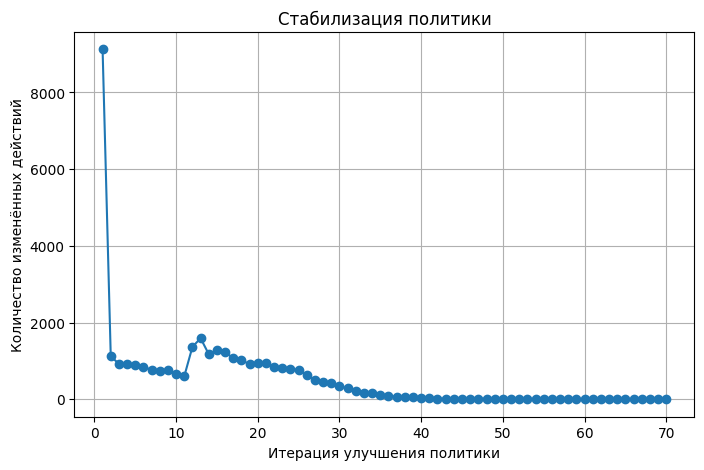

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(result.history["policy_iteration"], result.history["policy_changes"], marker="o")
plt.xlabel("Итерация улучшения политики")
plt.ylabel("Количество изменённых действий")
plt.title("Стабилизация политики")
plt.grid(True)
plt.show()

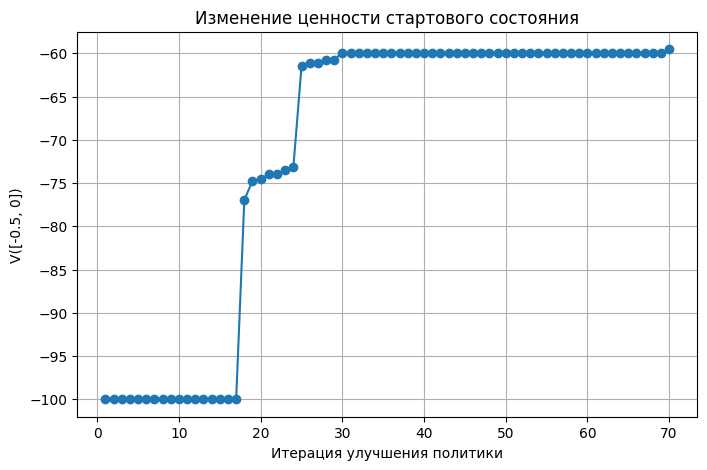

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(result.history["policy_iteration"], result.history["V_start_-0.5_0"], marker="o")
plt.xlabel("Итерация улучшения политики")
plt.ylabel("V([-0.5, 0])")
plt.title("Изменение ценности стартового состояния")
plt.grid(True)
plt.show()

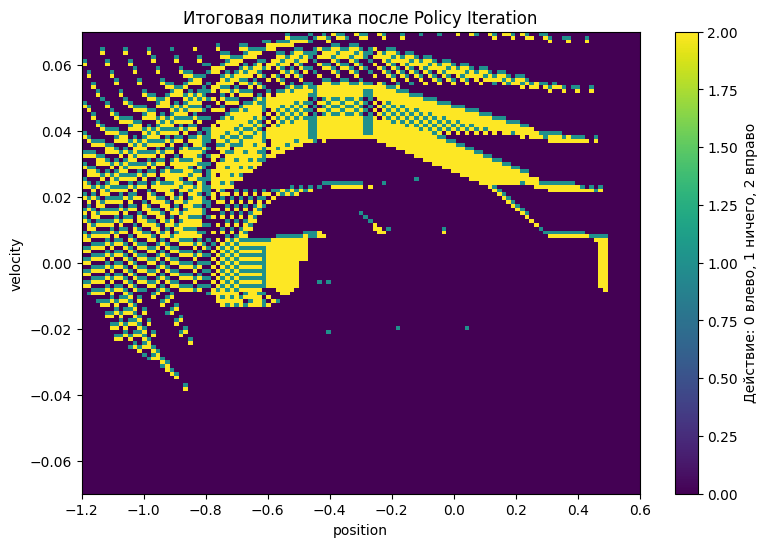

In [14]:
policy_grid = result.policy.reshape(N_POSITION_BINS, N_VELOCITY_BINS)

plt.figure(figsize=(9, 6))
plt.imshow(
    policy_grid.T,
    origin="lower",
    aspect="auto",
    extent=[base_env.min_position, base_env.max_position, -base_env.max_speed, base_env.max_speed],
)
plt.colorbar(label="Действие: 0 влево, 1 ничего, 2 вправо")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Итоговая политика после Policy Iteration")
plt.show()

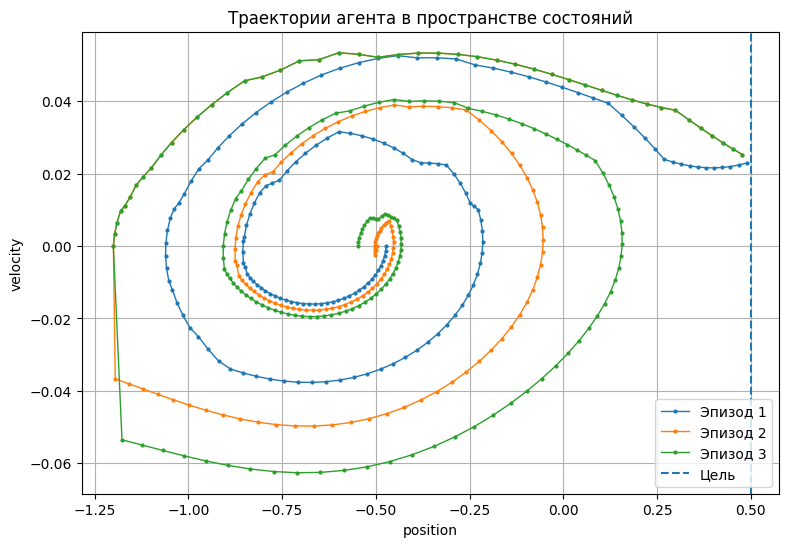

In [15]:
plt.figure(figsize=(9, 6))
for episode_id, group in trajectories_df.groupby("episode"):
    plt.plot(group["position"], group["velocity"], marker="o", markersize=2, linewidth=1, label=f"Эпизод {episode_id}")
plt.axvline(base_env.goal_position, linestyle="--", label="Цель")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Траектории агента в пространстве состояний")
plt.legend()
plt.grid(True)
plt.show()

## 13. Итог

В лабораторной работе был реализован алгоритм **Policy Iteration** для среды `MountainCar-v0`.

Особенности реализации:

1. Среда имеет непрерывное состояние, поэтому была выполнена дискретизация признаков `position` и `velocity`.
2. На дискретной сетке была построена модель MDP: следующие состояния, награды и терминальные переходы.
3. Алгоритм Policy Iteration состоял из двух шагов:
   - оценка текущей политики;
   - улучшение политики жадным выбором действия.
4. После стабилизации политики была проведена проверка на нескольких эпизодах.

Вывод: Policy Iteration можно применить к средам с непрерывным состоянием, если предварительно преобразовать их в конечное дискретное MDP. При увеличении числа интервалов дискретизации качество политики обычно растёт, но время вычислений также увеличивается.